SUPPORT VECTOR MACHINE

Dataset Selection:
Data set Description described in another document “Drug Response Classification”
Task 1: Exploratory Data Analysis (EDA)
1.Load the dataset and perform fundamental data exploration.
2.Utilize histograms, box plots, or density plots to understand feature distributions.
3.Investigate feature correlations to discern relationships within the data.
Task 2: Data Preprocessing
1.Encode categorical variables if necessary.
2.Split the dataset into training and testing sets.
Task 3: Data Visualization
1.Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.
2.Visualize class distributions to gauge dataset balance or imbalance.
Task 4: SVM Implementation
1.Implement a basic SVM classifier using Python libraries like scikit-learn.
2.Train the SVM model on the training data.
3.Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).
Task 5: Visualization of SVM Results
1.Visualize classification results on the testing data.
Task 6: Parameter Tuning and Optimization
1.Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.
Task 7: Comparison and Analysis
1.Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).
2.Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.
3.Discuss practical implications of SVM in real-world classification tasks.


Task 1: Exploratory Data Analysis (EDA)
1.Load the dataset and perform fundamental data exploration.
2.Utilize histograms, box plots, or density plots to understand feature distributions.
3.Investigate feature correlations to discern relationships within the data.

In [2]:
import pandas as pd
import numpy as np

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
df = pd.read_csv("Pharma_Industry.csv")
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [5]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
print(df.describe(include='all'))

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset: (500, 6)

Column Names:
Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

Data Types:
Drug Dosage (mg)                  float64
Systolic Blood Pressure (mmHg)    float64
Heart Rate (BPM)                  float64
Liver Toxicity Index (U/L)        float64
Blood Glucose Level (mg/dL)       float64
Drug Response                       int64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null   

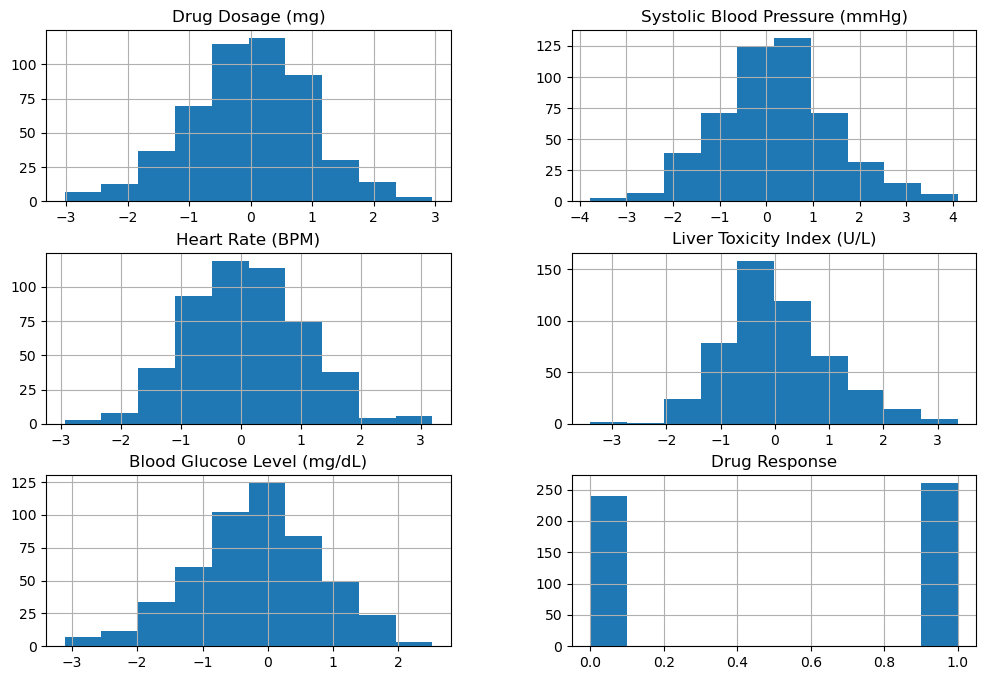

In [6]:
import matplotlib.pyplot as plt
df.hist(figsize=(12,8))
plt.show()

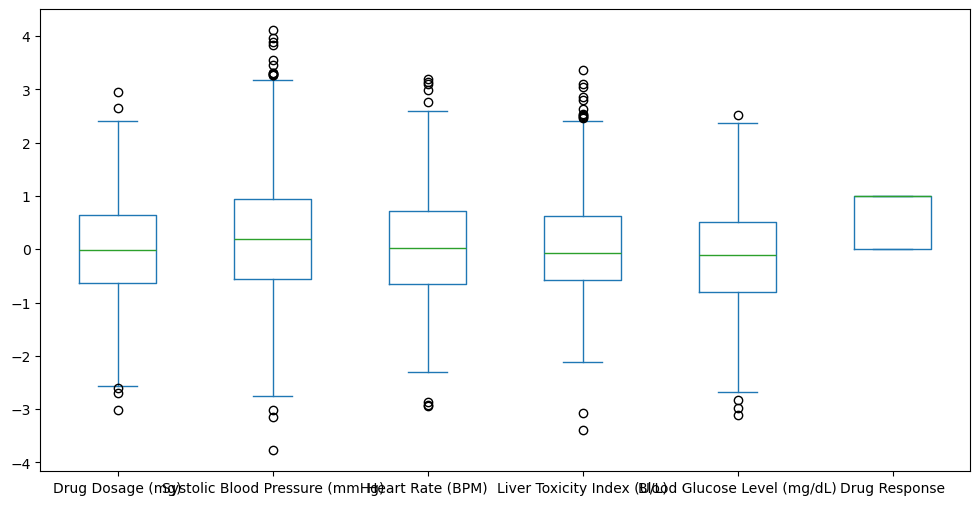

In [7]:
df.plot(kind='box', figsize=(12,6))
plt.show()

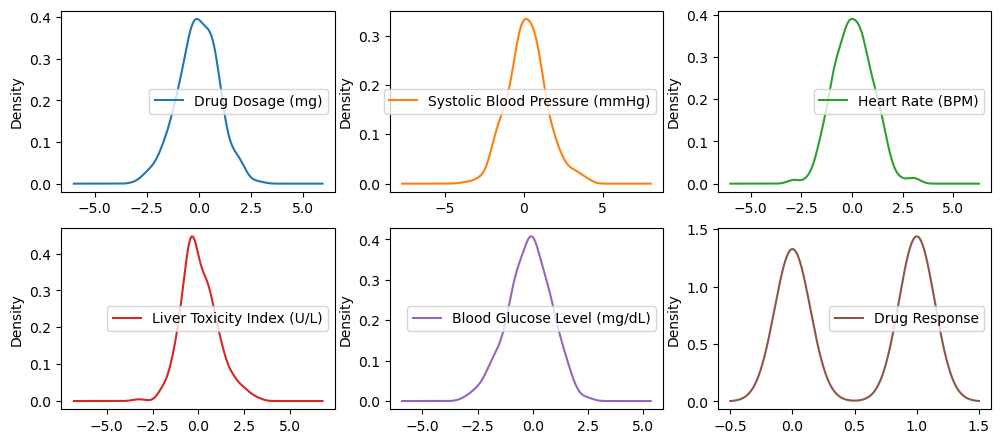

In [8]:
df.plot(kind='density', subplots=True, layout=(3,3), figsize=(12,8), sharex=False)
plt.show()

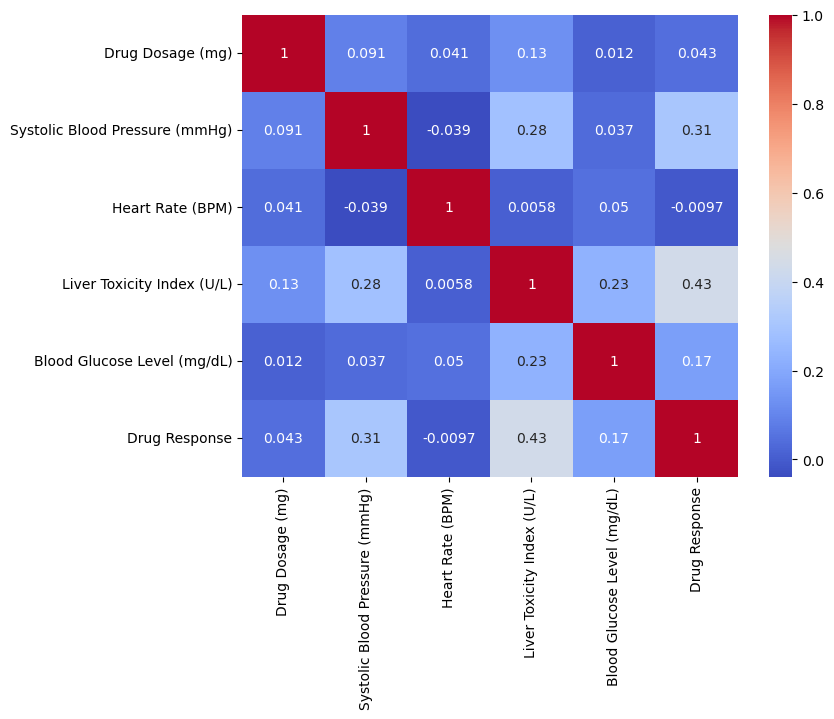

In [9]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

Task 2: Data Preprocessing
1.Encode categorical variables if necessary.
2.Split the dataset into training and testing sets.

In [10]:
df.select_dtypes(include=['object']).columns

Index([], dtype='object')

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [12]:
print(df.columns)

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')


In [14]:
from sklearn.model_selection import train_test_split

X = df.drop("Drug Response", axis=1)
y = df["Drug Response"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (400, 5)
Testing Data: (100, 5)


In [22]:
from sklearn.preprocessing import StandardScaler
scaler =StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Task 3: Data Visualization
1.Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.
2.Visualize class distributions to gauge dataset balance or imbalance.

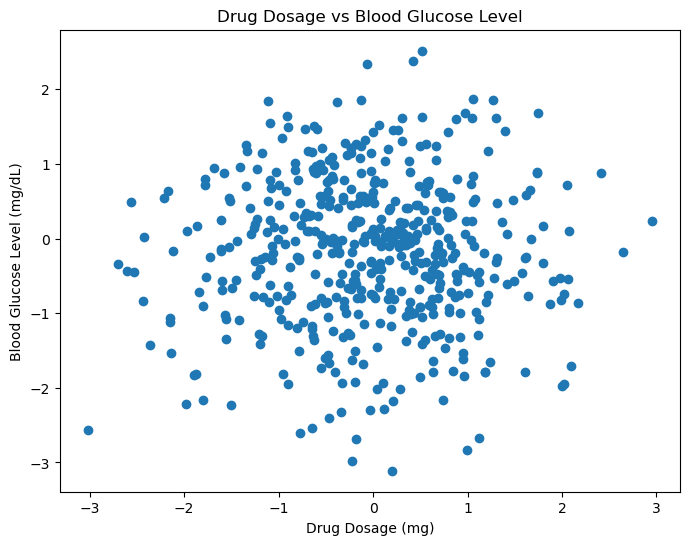

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df["Drug Dosage (mg)"], df["Blood Glucose Level (mg/dL)"])
plt.xlabel("Drug Dosage (mg)")
plt.ylabel("Blood Glucose Level (mg/dL)")
plt.title("Drug Dosage vs Blood Glucose Level")
plt.show()

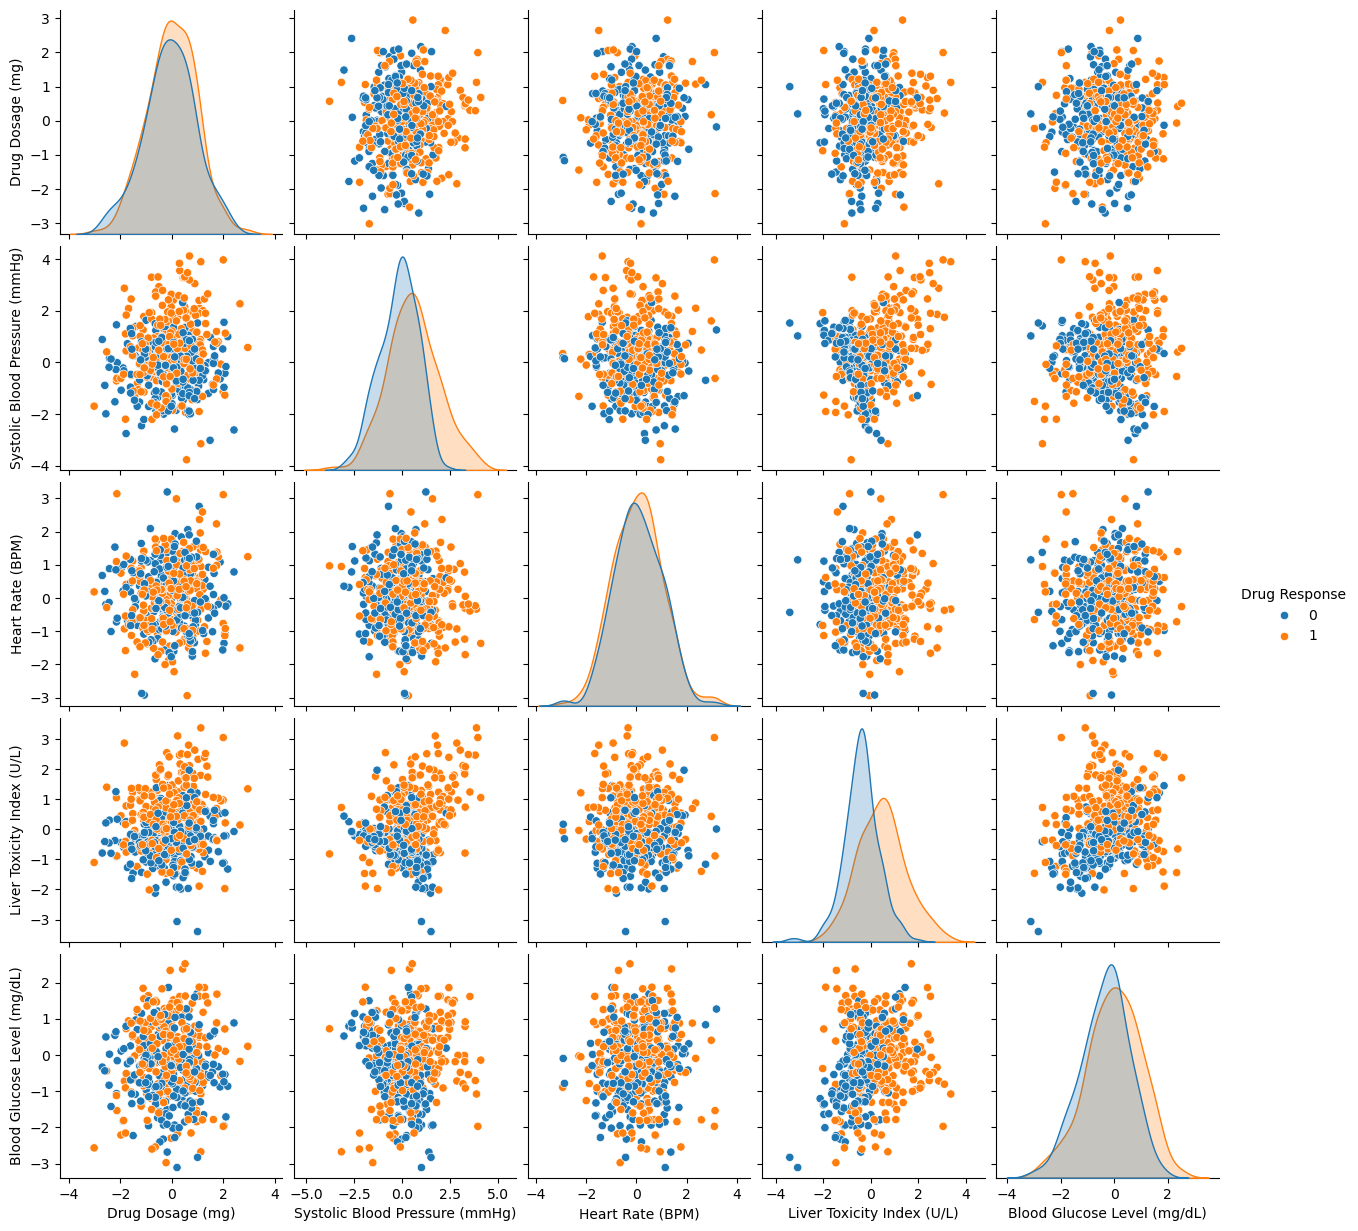

In [24]:
import seaborn as sns
sns.pairplot(df, hue="Drug Response")
plt.show()

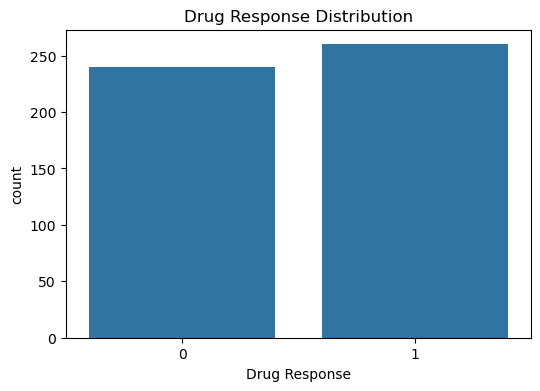

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.countplot(x="Drug Response", data=df)
plt.title("Drug Response Distribution")
plt.show()

Task 4: SVM Implementation
1.Implement a basic SVM classifier using Python libraries like scikit-learn.
2.Train the SVM model on the training data.
3.Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).

In [26]:
from sklearn.svm import SVC
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
print("SVM Model Trained Successfully!")

SVM Model Trained Successfully!


In [27]:
y_pred = svm_model.predict(X_test)
print("Predicted Values:")
print(y_pred[:10])

Predicted Values:
[0 0 0 0 0 0 0 0 0 0]


In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.78
Precision: 0.84
Recall   : 0.75
F1 Score : 0.7924528301886793


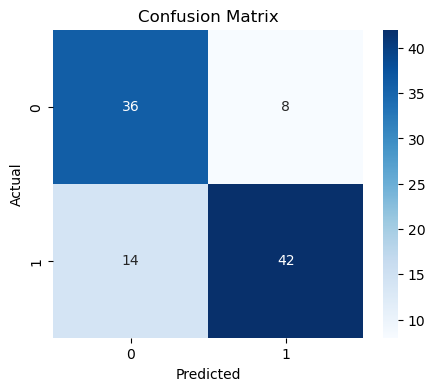

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [30]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.82      0.77        44
           1       0.84      0.75      0.79        56

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100



Task 5: Visualization of SVM Results
1.Visualize classification results on the testing data.

In [31]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,1,0
3,1,0
4,0,0
5,0,0
6,1,0
7,1,0
8,0,0
9,1,0


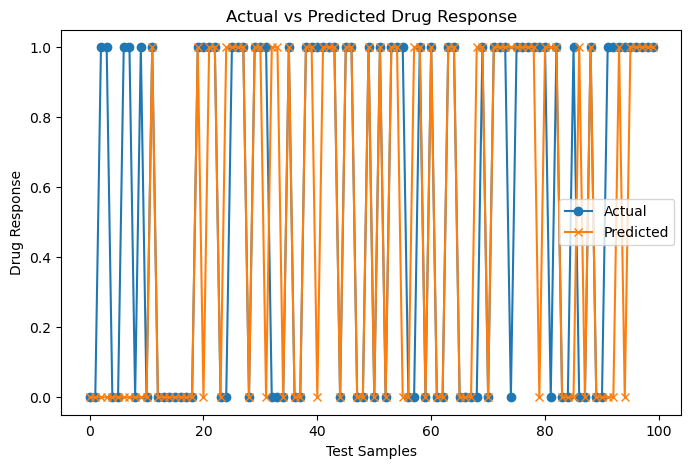

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(results["Actual"].values, label="Actual", marker='o')
plt.plot(results["Predicted"].values, label="Predicted", marker='x')

plt.title("Actual vs Predicted Drug Response")
plt.xlabel("Test Samples")
plt.ylabel("Drug Response")
plt.legend()
plt.show()

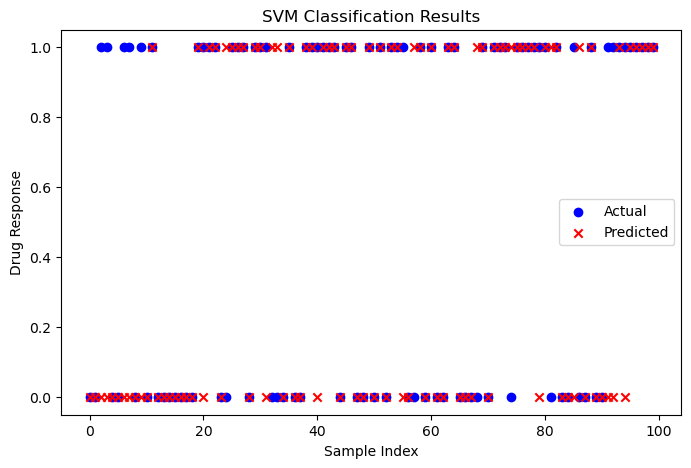

In [33]:
plt.figure(figsize=(8,5))

plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual')
plt.scatter(range(len(y_pred)), y_pred, color='red', marker='x', label='Predicted')

plt.title("SVM Classification Results")
plt.xlabel("Sample Index")
plt.ylabel("Drug Response")
plt.legend()
plt.show()

Task 6: Parameter Tuning and Optimization
1.Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.


In [34]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

print("Linear Kernel Accuracy:", accuracy_score(y_test, y_pred_linear))

Linear Kernel Accuracy: 0.78


In [35]:
svm_poly = SVC(kernel='poly', degree=3, C=1)
svm_poly.fit(X_train, y_train)

y_pred_poly = svm_poly.predict(X_test)

print("Polynomial Kernel Accuracy:", accuracy_score(y_test, y_pred_poly))

Polynomial Kernel Accuracy: 0.71


In [36]:
svm_rbf = SVC(kernel='rbf', C=1)
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

print("RBF Kernel Accuracy:", accuracy_score(y_test, y_pred_rbf))

RBF Kernel Accuracy: 0.84


In [37]:
comparison = pd.DataFrame({
    "Kernel": ["Linear", "Polynomial", "RBF"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_linear),
        accuracy_score(y_test, y_pred_poly),
        accuracy_score(y_test, y_pred_rbf)
    ]
})

comparison

,Kernel,Accuracy
0,Linear,0.78
1,Polynomial,0.71
2,RBF,0.84


In [38]:
best_kernel = comparison.loc[comparison["Accuracy"].idxmax()]

print("Best Kernel:")
print(best_kernel)

Best Kernel:
Kernel       RBF
Accuracy    0.84
Name: 2, dtype: object


Task 7: Comparison and Analysis
1.Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).
2.Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.
3.Discuss practical implications of SVM in real-world classification tasks.


| Kernel                          | Advantages                                         | Disadvantages                                           |
| ------------------------------- | -------------------------------------------------- | ------------------------------------------------------- |
| **Linear**                      | Fast, simple, suitable for linearly separable data | Performs poorly on complex non-linear data              |
| **Polynomial**                  | Captures non-linear relationships                  | Slower training and may overfit                         |
| **RBF (Radial Basis Function)** | Handles complex and non-linear data effectively    | Computationally expensive and requires parameter tuning |


2..Strengths
Effective for both linear and non-linear classification.
Performs well on high-dimensional datasets.
Provides good generalization with proper parameter tuning.
Works well for binary classification problems.
Weaknesses
Training can be slow for very large datasets.
Selecting the appropriate kernel and parameters can be challenging.
Less interpretable compared to decision trees.

3..Practical Implications
SVM is widely used in medical diagnosis to classify diseases and predict patient outcomes.
It is applied in the pharmaceutical industry to predict drug response and improve personalized medicine.
SVM is also used for spam email detection, image classification, face recognition, and text classification.
Choosing the right kernel and tuning hyperparameters can significantly improve classification performance.